# **Step 1: 라이브러리 임포트 및 데이터 준비**
**먼저 필요한 도구들을 다운로드하고, 불러오고, 이미지 데이터를 모델이 읽을 수 있는 형태로 변환합니다.**

In [1]:
!pip install tensorflow
!pip install keras
!pip install pillow

In [2]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive/')
%cd '/content/drive/MyDrive/AI/의료 데이터 분석'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive/AI/의료 데이터 분석


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. 경로 설정 (사용자 환경에 맞게 수정 필요)
base_dir = 'chest_xray/X-ray(데이터셋)' # 데이터셋이 있는 폴더 경로
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# 2. 이미지 데이터 제너레이터 설정
# 학습 데이터에는 증강(Augmentation)을 적용하여 과적합을 방지합니다.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# 검증 및 테스트 데이터는 스케일만 조정합니다.
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. 데이터 로드
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150), # 모델에 들어갈 이미지 크기
    batch_size=32,
    class_mode='binary'      # 정상/폐렴 이진 분류
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
print("데이터 준비 완료!")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
데이터 준비 완료!


# **Step 2: CNN 모델 설계 및 컴파일**

In [4]:
from tensorflow.keras import layers, models

# 1. 모델 아키텍처 설계
model = models.Sequential([
    # 첫 번째 Convolution 층: 이미지의 저수준 특징(선, 면 등) 추출
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # 두 번째 Convolution 층: 더 복잡한 특징 추출
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 세 번째 Convolution 층
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 네 번째 Convolution 층
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 데이터를 1차원으로 펼치기
    layers.Flatten(),

    # 과적합 방지를 위한 Dropout (노드의 50%를 무작위로 끔)
    layers.Dropout(0.5),

    # Dense 층 (Full Connected)
    layers.Dense(512, activation='relu'),

    # 최종 출력층: 이진 분류이므로 sigmoid 활성화 함수 사용 (0~1 사이 값)
    layers.Dense(1, activation='sigmoid')
])

# 2. 모델 설정 (Compile)
model.compile(
    loss='binary_crossentropy', # 이진 분류용 손실 함수
    optimizer='adam',           # 가장 대중적인 최적화 도구
    metrics=['accuracy', tf.keras.metrics.Recall()] # 정확도와 재현율(Recall) 확인
)

# 3. 모델 구조 요약 출력
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

# **Step 3: 모델 학습 및 결과 시각화**
**이 코드 블록에서는 학습 효율을 높이기 위해 콜백 기능을 추가했습니다. 학습이 잘 안 오르면 스스로 멈추거나 학습 속도를 조절하는 똑똑한 기능입니다.**

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7635 - loss: 0.5394 - recall: 0.9701

163/163 ━━━━━━━━━━━━━━━━━━━━ 727s 4s/step - accuracy: 0.8135 - loss: 0.4314 - recall: 0.9517 - val_accuracy: 0.5625 - val_loss: 1.4275 - val_recall: 1.0000
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.8836 - loss: 0.2830 - recall: 0.9370

163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 601ms/step - accuracy: 0.8917 - loss: 0.2618 - recall: 0.9303 - val_accuracy: 0.6875 - val_loss: 0.8914 - val_recall: 1.0000
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9188 - loss: 0.2090 - recall: 0.9442

163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 599ms/step - accuracy: 0.9195 - loss: 0.2047 - recall: 0.9450 - val_accuracy: 0.6250 - val_loss: 0.7930 - val_recall: 0.8750
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 580ms/step - accuracy: 0.9264 - loss: 0.1905 - recall: 0.9502 - val_accuracy: 0.6875 - val_loss: 0.9068 - val_recall: 1.0000
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 565ms/step - accuracy: 0.9325 - loss: 0.1742 - recall: 0.9538 - val_accuracy: 0.6250 - val_loss: 0.9701 - val_recall: 1.0000
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 568ms/step - accuracy: 0.9379 - loss: 0.1653 - recall: 0.9577 - val_accuracy: 0.6250 - val_loss: 1.0117 - val_recall: 1.0000
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9321 - loss: 0.1624 - recall: 0.9556

163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 565ms/step - accuracy: 0.9350 - loss: 0.1600 - recall: 0.9561 - val_accuracy: 0.6875 - val_loss: 0.4484 - val_recall: 0.8750
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 571ms/step - accuracy: 0.9423 - loss: 0.1600 - recall: 0.9592 - val_accuracy: 0.6875 - val_loss: 0.6676 - val_recall: 1.0000
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 559ms/step - accuracy: 0.9456 - loss: 0.1467 - recall: 0.9626 - val_accuracy: 0.5625 - val_loss: 1.0129 - val_recall: 1.0000
Epoch 10/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 565ms/step - accuracy: 0.9433 - loss: 0.1493 - recall: 0.9605 - val_accuracy: 0.6250 - val_loss: 0.6274 - val_recall: 0.8750
Epoch 11/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 577ms/step - accuracy: 0.9446 - loss: 0.1418 - recall: 0.9600 - val_accuracy: 0.5625 - val_loss: 0.7456 - val_recall: 0.7500
Epoch 12/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 575ms/step - accuracy: 0.9461 - loss: 0.1377 - recall: 0.9605 - val_accuracy: 0.5625 - val_loss: 1.0878 - val_recall: 1

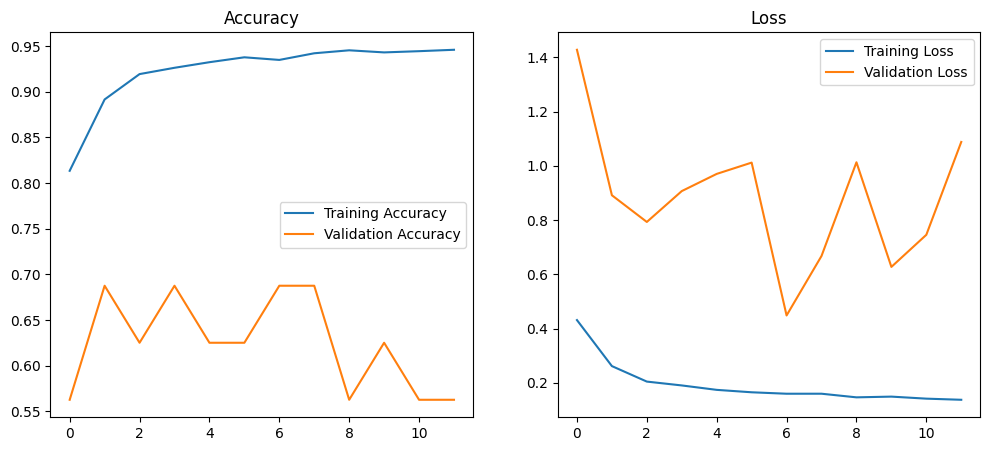

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. 콜백 설정
# 5번의 에포크(Epoch) 동안 성능 향상이 없으면 조기 종료
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 가장 성능이 좋았던 모델의 가중치를 저장
checkpoint = ModelCheckpoint('best_pneumonia_model.h5', monitor='val_loss', save_best_only=True)

# 2. 모델 학습 시작
# 학습 시간이 수 분 정도 소요될 수 있습니다. (T4 GPU 사용 권장)
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=20, # 최대 20번 반복 학습
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[early_stopping, checkpoint]
)

# 3. 학습 결과 시각화
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

# **Step 4: 모델 평가 및 테스트**

In [6]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

# 1. 테스트 데이터셋으로 최종 성능 평가
test_loss, test_acc, test_recall = model.evaluate(validation_generator)
print(f"테스트 정확도: {test_acc:.2%}")
print(f"테스트 재현율(Recall): {test_recall:.2%}")

# 2. 새로운 이미지를 업로드해서 예측해보기
def predict_pneumonia():
    print("\n판독할 X-ray 사진을 업로드해주세요.")
    uploaded = files.upload()

    for fn in uploaded.keys():
        # 이미지 로드 및 전처리
        path = fn
        img = image.load_img(path, target_size=(150, 150))
        img_tensor = image.img_to_array(img)
        img_tensor = np.expand_dims(img_tensor, axis=0)
        img_tensor /= 255.

        # 예측
        prediction = model.predict(img_tensor)

        # 결과 출력
        if prediction[0][0] > 0.5:
            print(f"==> {fn}: {prediction[0][0]*100:.2f}% 확률로 [폐렴]이 의심됩니다.")
        else:
            print(f"==> {fn}: {(1-prediction[0][0])*100:.2f}% 확률로 [정상] 소견입니다.")

# 함수 실행 (업로드 버튼이 뜹니다)
predict_pneumonia()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.6875 - loss: 0.4484 - recall: 0.8750
테스트 정확도: 68.75%
테스트 재현율(Recall): 87.50%

판독할 X-ray 사진을 업로드해주세요.


Saving 폐렴 이미지.jpg to 폐렴 이미지.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
==> 폐렴 이미지.jpg: 97.11% 확률로 [폐렴]이 의심됩니다.
